# Dependencies

In [60]:
import sys
from pathlib import Path

parent_dir = str(Path().resolve().parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

In [ ]:
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, recall_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [128]:
%load_ext autoreload
%autoreload 2

from src.dataset import Dataloader

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Fetching dataset

In [132]:
dataloader_config = {
    "time_per_datapoint_s": 1,
}
dataloader = Dataloader(dataloader_config)
dataset = dataloader.get_data()

146it [00:13,  7.70it/s]

[ERROR] Failed to process column X175_DE_time in 175.mat: Length of values (381890) does not match length of index (489125)
[ERROR] Failed to process column X175_FE_time in 175.mat: Length of values (381890) does not match length of index (489125)


152it [00:15,  4.58it/s]

[ERROR] Failed to process column X217_DE_time in 217.mat: Length of values (489125) does not match length of index (491446)
[ERROR] Failed to process column X217_FE_time in 217.mat: Length of values (489125) does not match length of index (491446)


203it [00:25,  3.44it/s]

[ERROR] Failed to process column X099_DE_time in 99.mat: Length of values (485063) does not match length of index (483903)
[ERROR] Failed to process column X099_FE_time in 99.mat: Length of values (485063) does not match length of index (483903)


204it [00:25,  7.87it/s]


In [133]:
dataset

,feat_avg_power,feat_narrowband_power_rate,feat_most_relevant_binned_freq,feat_most_relevant_binned_power,feat_binned_fft_power_bin_0,feat_binned_fft_power_bin_1,feat_binned_fft_power_bin_2,feat_binned_fft_power_bin_3,feat_binned_fft_power_bin_4,feat_binned_fft_power_bin_5,...,feat_dominant_freq,feat_kurtosis,mat_file,sampling_rate,motor_load_hp,motor_speed_rpm,fault_position,fault_type,fault_size_in,telemetry_position
0,0.008065,0.824710,3899.5,437272.747678,0.049988,0.049241,0.072528,0.013876,0.006491,0.019874,...,3634.0,2.335340,/home/lmres/storage/projects/cwru-fault-detect...,12000,0,1797,fan,inner,0.007,BA_0
1,0.008117,0.819063,3899.5,436075.489501,0.061459,0.046462,0.069102,0.014232,0.006098,0.020499,...,3635.0,2.337816,/home/lmres/storage/projects/cwru-fault-detect...,12000,0,1797,fan,inner,0.007,BA_0
2,0.008167,0.810644,3899.5,435844.059116,0.063535,0.049550,0.072450,0.013109,0.006117,0.018417,...,3635.0,2.357269,/home/lmres/storage/projects/cwru-fault-detect...,12000,0,1797,fan,inner,0.007,BA_0
3,0.008125,0.811053,3899.5,433969.830804,0.072614,0.047382,0.065583,0.011873,0.006200,0.019507,...,3635.0,2.340858,/home/lmres/storage/projects/cwru-fault-detect...,12000,0,1797,fan,inner,0.007,BA_0
4,0.008177,0.805523,3899.5,433633.672228,0.078218,0.045019,0.067308,0.012657,0.006586,0.018992,...,3635.0,2.360613,/home/lmres/storage/projects/cwru-fault-detect...,12000,0,1797,fan,inner,0.007,BA_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4133,0.006888,0.139491,299.5,347813.940195,0.614166,0.227633,0.017494,0.136984,0.000465,0.000256,...,0.0,2.964948,/home/lmres/storage/projects/cwru-fault-detect...,12000,3,1730,,NaN,NaN,FE_0
4134,0.006702,0.139884,299.5,339081.688841,0.605874,0.233102,0.019998,0.137822,0.000422,0.000242,...,0.0,3.096287,/home/lmres/storage/projects/cwru-fault-detect...,12000,3,1730,,NaN,NaN,FE_0
4135,0.006555,0.147002,299.5,352049.862321,0.642525,0.190000,0.019218,0.144956,0.000462,0.000237,...,0.0,2.984123,/home/lmres/storage/projects/cwru-fault-detect...,12000,3,1730,,NaN,NaN,FE_0
4136,0.006505,0.145336,299.5,327515.361332,0.609452,0.224490,0.019463,0.143223,0.000458,0.000263,...,0.0,2.974487,/home/lmres/storage/projects/cwru-fault-detect...,12000,3,1730,,NaN,NaN,FE_0


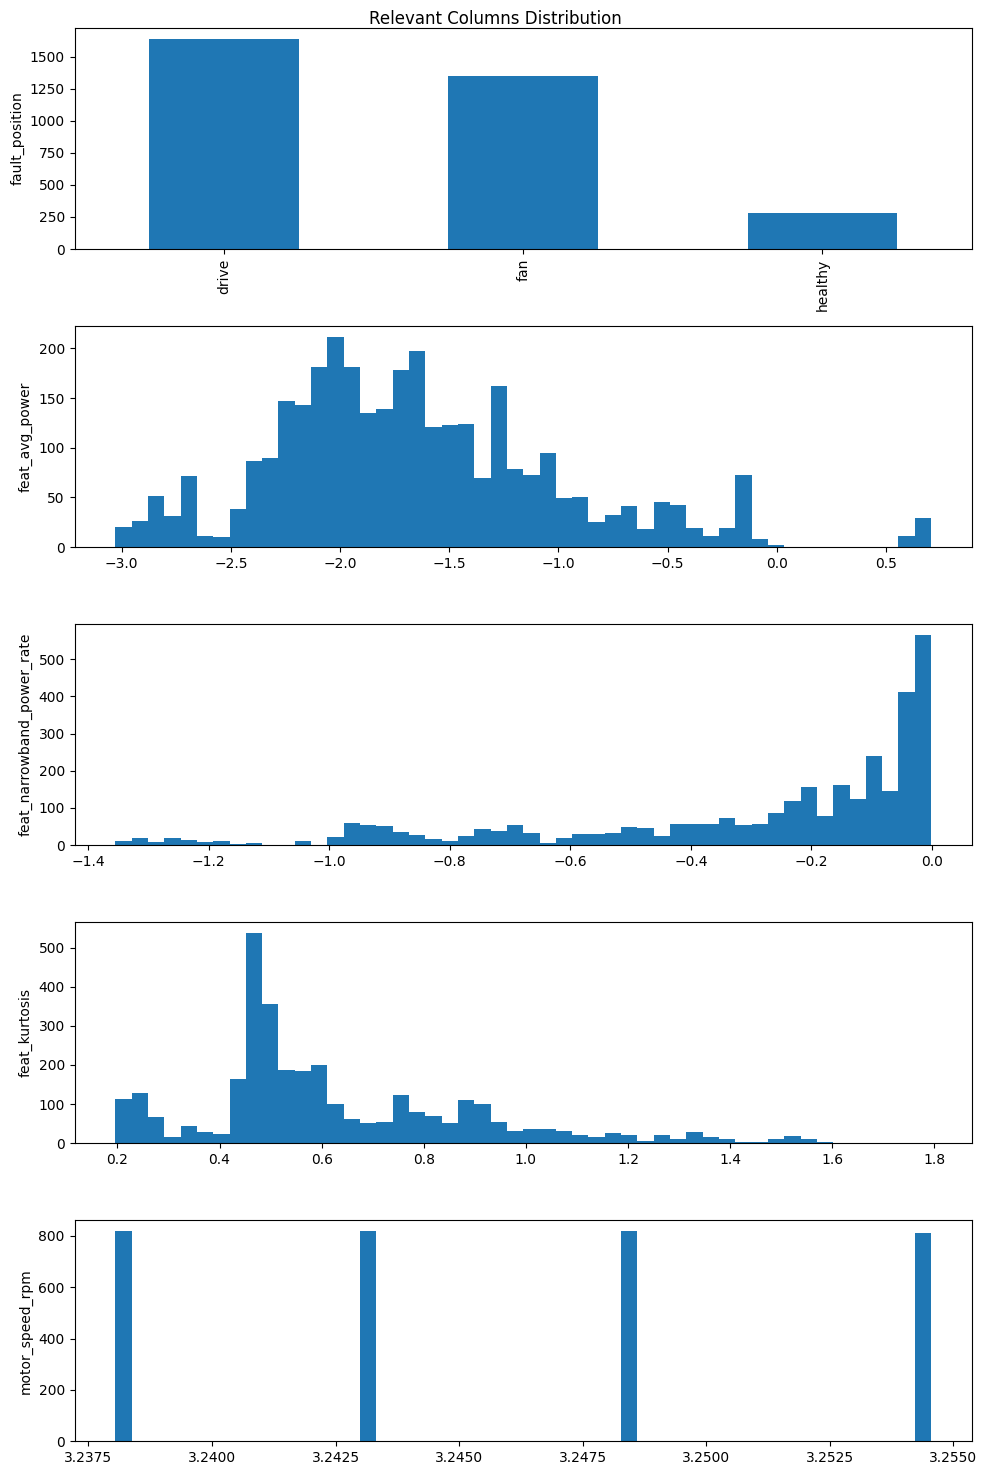

In [68]:
relevant_columns = [
    "fault_position",
    "feat_avg_power",
    "feat_narrowband_power_rate",
    "feat_kurtosis",
    "motor_speed_rpm",
]
curr_dataset = dataset.copy()
healthy_mask = curr_dataset["fault_type"].isna() | curr_dataset["fault_position"].isna()
curr_dataset.loc[healthy_mask, "fault_type"] = "healthy"
curr_dataset.loc[healthy_mask, "fault_position"] = "healthy"

# curr_dataset = curr_dataset[curr_dataset["fault_type"] == "healthy"]

fig, axs = plt.subplots(len(relevant_columns), 1, figsize=(10, 3 * len(relevant_columns)))
for i, col in enumerate(relevant_columns):
    if curr_dataset[col].dtype == "str" or curr_dataset[col].dtype == "category":
        curr_dataset[col] = curr_dataset[col].astype("category")
        curr_dataset[col].value_counts().plot(kind="bar", ax=axs[i])
    elif curr_dataset[col].dtype == "float64" or curr_dataset[col].dtype == "int64":
        curr_dataset[col].apply(np.log10).hist(bins=50, ax=axs[i])
    else:
        print(f"Column {col} has unsupported dtype {curr_dataset[col].dtype}")
        continue
    axs[i].set_ylabel(col)
    axs[i].set_xlabel("")
    axs[i].grid(False)

fig.suptitle("Relevant Columns Distribution")
fig.tight_layout()

Theres an imbalance between the classes, so we must develop some method to oversample the healthy label later on. 

Logarithms may be applied to the data in order to distribute more evenly the feature values.

# Model Proposal 1

A model that detects if theres a fault at all, not discriminating type or position relative to sensor. It receives one sensor readings and computes how likely that signal represents a fault.
- classifier based on features
- anomaly detection on the time series (moving window z-score or other metrics)

In [72]:
curr_dataset = dataset.copy().sample(frac=1, random_state=42)
curr_dataset["has_fault"] = curr_dataset["fault_type"].notna()
curr_dataset["feat_avg_power"] = curr_dataset["feat_avg_power"].apply(np.log1p)
curr_dataset["feat_narrowband_power_rate"] = curr_dataset["feat_narrowband_power_rate"].apply(np.log1p)
curr_dataset["feat_kurtosis"] = curr_dataset["feat_kurtosis"].apply(np.log1p)

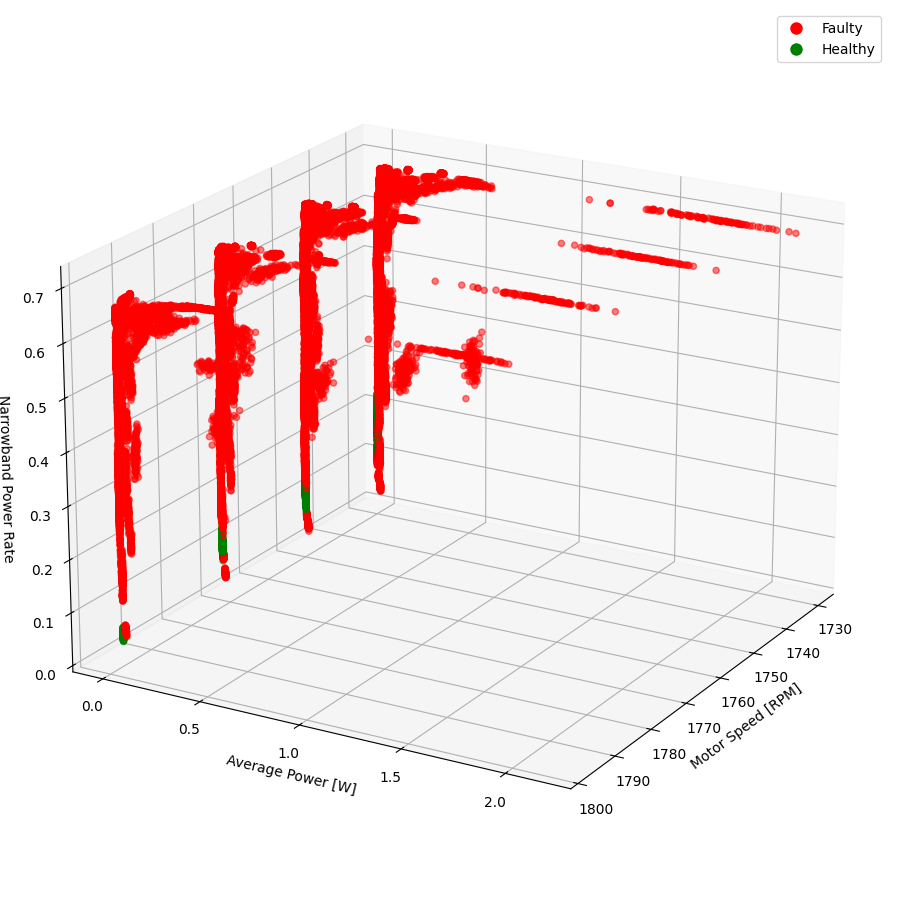

In [47]:
fig = plt.figure(figsize=(8,6),dpi=100)
ax = fig.add_subplot(projection='3d', elev=20, azim=30)

ax.scatter(
    xs=curr_dataset["motor_speed_rpm"],
    ys=curr_dataset["feat_avg_power"],
    zs=curr_dataset["feat_narrowband_power_rate"],
    c=curr_dataset["has_fault"].map({True: "red", False: "green"}),
    alpha=0.5,
)
ax.set_xlabel("Motor Speed [RPM]")
ax.set_ylabel("Average Power [W]")
ax.set_zlabel("Narrowband Power Rate")
ax.legend(handles=[
    plt.plot([],[], marker='o', color='w', label='Faulty', markerfacecolor='red', markersize=10)[0],
    plt.plot([],[], marker='o', color='w', label='Healthy', markerfacecolor='green', markersize=10)[0]
])
fig.tight_layout(pad=-10)

In [26]:
models = {
    "XGBClassifier": XGBClassifier(
        n_estimators=5, 
        max_depth=3, 
        learning_rate=1, 
        objective='binary:logistic',
        scale_pos_weight=curr_dataset["has_fault"].value_counts()[False] / curr_dataset["has_fault"].value_counts()[True],
    ),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "SVC": make_pipeline(StandardScaler(), SVC(class_weight='balanced')),
}

In [94]:
def k_fold(
        dataset: pd.DataFrame, 
        k: int = 5, 
        oversample: bool = False,
        input_columns:list = ["motor_speed_rpm","feat_avg_power","feat_narrowband_power_rate"],
        output_columns:list = ["has_fault"]
    ):
    
    X = dataset[input_columns].values
    y = dataset[output_columns].values

    folds = np.array_split(np.arange(len(X)), k)
    for i in range(k):
        test_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        
        if oversample:
            n_per_class = np.unique(y[train_idx], return_counts=True) # [[labels], [counts]]
            diffs = n_per_class[1].max() - n_per_class[1]
            for class_value, n_samples in zip(n_per_class[0], diffs):
                if n_samples > 0:
                    class_idx = train_idx[y[train_idx] == class_value]
                    oversampled_idx = np.random.choice(class_idx, size=n_samples, replace=True)
                    train_idx = np.concatenate([train_idx, oversampled_idx])

        yield X[train_idx], y[train_idx], X[test_idx], y[test_idx]

In [50]:
preds = defaultdict(lambda: defaultdict(list))
for model_name, model in models.items():
    for X_train, y_train, X_test, y_test in k_fold(curr_dataset, k=5):
        model.fit(X_train, y_train.ravel())
        # score = model.score(X_test, y_test)
        # classification_report_str = classification_report(y_test, y_pred, target_names=["Healthy", "Faulty"])
        y_pred = model.predict(X_test)

        cm = confusion_matrix(y_test.ravel(), y_pred)
        preds[model_name]["cm"].append(cm)
        tn, fp, fn, tp = cm.ravel()
        preds[model_name]["recall"].append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        preds[model_name]["specificity"].append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        preds[model_name]["precision"].append(tp / (tp + fp) if (tp + fp) > 0 else 0)

In [49]:
print("Model Performance Metrics:")
for model_name in preds.keys():
    recall_min = np.min(preds[model_name]['recall']) * 100
    recall_max = np.max(preds[model_name]['recall']) * 100
    specificity_min = np.min(preds[model_name]['specificity']) * 100
    specificity_max = np.max(preds[model_name]['specificity']) * 100
    precision_min = np.min(preds[model_name]['precision']) * 100
    precision_max = np.max(preds[model_name]['precision']) * 100

    print(f"{model_name}:")
    print(f"\tRecall: [{recall_min:.2f}, {recall_max:.2f}]")
    print(f"\tSpecificity: [{specificity_min:.2f}, {specificity_max:.2f}]")
    print(f"\tPrecision: [{precision_min:.2f}, {precision_max:.2f}]")

Model Performance Metrics:
XGBClassifier:
	Recall: [98.53, 98.86]
	Specificity: [99.13, 99.83]
	Precision: [99.92, 99.98]
DecisionTreeClassifier:
	Recall: [99.73, 99.82]
	Specificity: [97.04, 98.56]
	Precision: [99.72, 99.87]
SVC:
	Recall: [91.97, 93.05]
	Specificity: [100.00, 100.00]
	Precision: [100.00, 100.00]


# Model Proposal 2
A multi-label classifier, to separate between types. In order to do that, it may be needed to extract patterns from the time series or its fft format for each fault.

- Extract the FFT -> train an auto-encoder as an embedding -> use its latent variables as input
- Collect the power from every telemetry position in order to determine the expected power from each fault at each position

Its still receives one sensor reading to make the inference.

In [138]:
curr_dataset = dataset.copy().sample(frac=1, random_state=42)
faulty_dataset = curr_dataset.copy()

In [139]:
curr_dataset["feat_avg_power"] = curr_dataset["feat_avg_power"].apply(np.log1p)
curr_dataset["feat_narrowband_power_rate"] = curr_dataset["feat_narrowband_power_rate"].apply(np.log1p)
curr_dataset["feat_kurtosis"] = curr_dataset["feat_kurtosis"].apply(np.log1p)

faulty_dataset["fault_size_in"] = faulty_dataset["fault_size_in"].apply(lambda x: x if pd.notna(x) else 0)
faulty_dataset["fault_type"] = faulty_dataset["fault_type"].apply(lambda x: "none" if not pd.notna(x) else "outer" if "outer" in x else x)
faults = faulty_dataset["fault_type"].unique().tolist()

encoder = OneHotEncoder()
encoded_fault_types = encoder.fit_transform(faulty_dataset[['fault_type']])
encoded_fault_types_df = pd.DataFrame(encoded_fault_types.toarray(), columns=encoder.get_feature_names_out(['fault_type']))
oh_faulty_dataset = pd.concat([faulty_dataset.drop(columns=['fault_type']).reset_index(drop=True), encoded_fault_types_df.reset_index(drop=True)], axis=1)
faulty_dataset.head()

,feat_avg_power,feat_narrowband_power_rate,feat_most_relevant_binned_freq,feat_most_relevant_binned_power,feat_binned_fft_power_bin_0,feat_binned_fft_power_bin_1,feat_binned_fft_power_bin_2,feat_binned_fft_power_bin_3,feat_binned_fft_power_bin_4,feat_binned_fft_power_bin_5,...,feat_dominant_freq,feat_kurtosis,mat_file,sampling_rate,motor_load_hp,motor_speed_rpm,fault_position,fault_type,fault_size_in,telemetry_position
1644,0.030597,0.563379,3299.5,4.715286e+05,0.142834,0.130920,0.056450,0.068233,0.124684,0.206198,...,0.0,3.776068,/home/lmres/storage/projects/cwru-fault-detect...,12000,1,1772,drive,inner,0.021,FE_0
134,0.032860,0.830083,3299.5,1.622660e+06,0.091432,0.046100,0.027464,0.011935,0.118619,0.685526,...,3217.0,3.729576,/home/lmres/storage/projects/cwru-fault-detect...,12000,0,1797,fan,inner,0.014,DE_0
411,0.013692,0.355986,299.5,3.623209e+05,0.350284,0.105981,0.003803,0.010004,0.050861,0.136061,...,0.0,2.925111,/home/lmres/storage/projects/cwru-fault-detect...,12000,1,1772,fan,ball,0.007,FE_0
203,0.017697,0.691002,3899.5,4.404319e+05,0.058012,0.094751,0.112856,0.015492,0.135185,0.112240,...,4120.0,5.611338,/home/lmres/storage/projects/cwru-fault-detect...,12000,2,1750,fan,inner,0.014,FE_0
1159,0.009691,0.797814,3299.5,3.471136e+05,0.060237,0.109422,0.022317,0.030742,0.251536,0.497018,...,2910.0,3.483902,/home/lmres/storage/projects/cwru-fault-detect...,12000,1,1772,fan,outer,0.021,DE_0


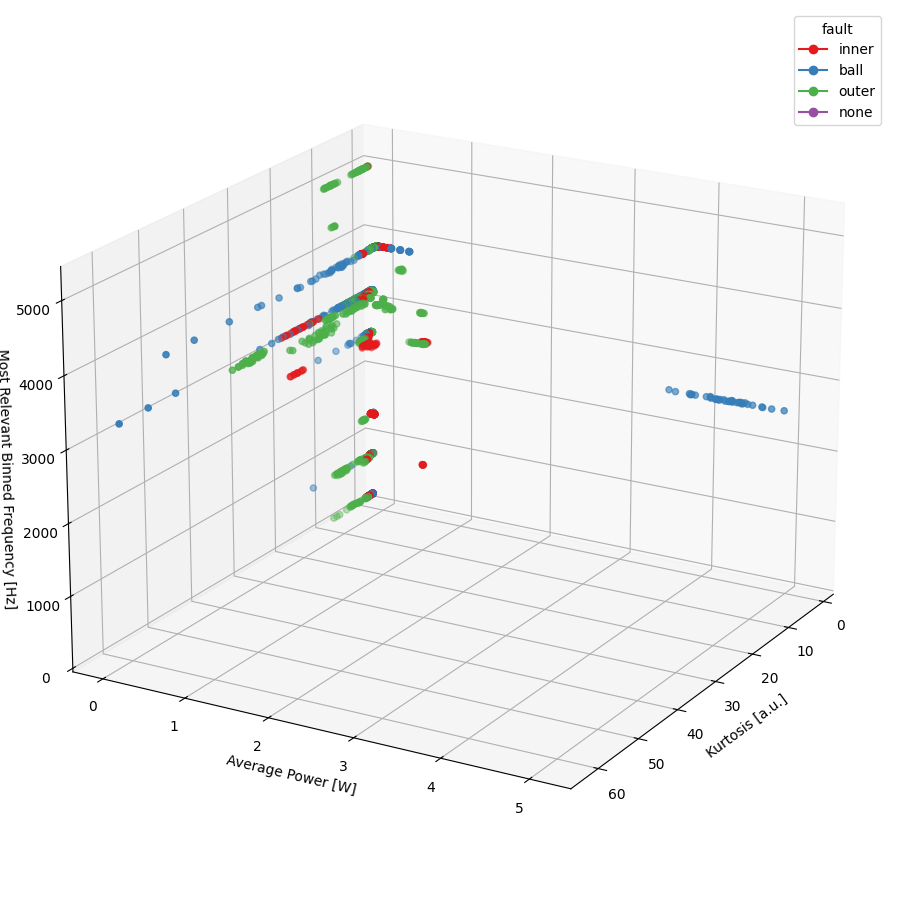

In [143]:
fig = plt.figure(figsize=(8,6),dpi=100)
ax = fig.add_subplot(projection='3d', elev=20, azim=30)

faulty_dataset["fault_type_c"] = faulty_dataset["fault_type"].apply(lambda x: faults.index(x))
cmap = plt.get_cmap("Set1")

ax.scatter(
    xs=faulty_dataset["feat_kurtosis"],
    ys=faulty_dataset["feat_avg_power"],
    zs=faulty_dataset["feat_most_relevant_binned_freq"],
    c=cmap(faulty_dataset["fault_type_c"]),
    # alpha=faulty_dataset["fault_size_in"],
)
# ax.set_xlabel("Motor Speed [RPM]")
ax.set_xlabel("Kurtosis [a.u.]")
ax.set_ylabel("Average Power [W]")
# ax.set_zlabel("Narrowband Power Rate")
ax.set_zlabel("Most Relevant Binned Frequency [Hz]")

handles = []
for i,label in enumerate(faults):
    handles.append(
        plt.plot([],[],label=label,color=cmap(i),marker='o')[0]
    )

ax.legend(title="fault")
fig.tight_layout(pad=-10)

In [144]:
models = {
    "xgboost": XGBClassifier(
        n_estimators=5, 
        max_depth=3, 
        learning_rate=1, 
        objective='binary:logistic',
        tree_method="hist"
    )
}

In [152]:
metrics = defaultdict(lambda: defaultdict(list))
input_columns = ["motor_speed_rpm","feat_avg_power","feat_narrowband_power_rate","feat_kurtosis"]\
    +dataset.filter(like="binned").columns.tolist()\
    +["feat_dominant_freq"]
output_columns = encoder.get_feature_names_out(["fault_type"])

for model_name, model in models.items():
    for X_train, y_train, X_test, y_test in k_fold(oh_faulty_dataset, k=5,input_columns=input_columns, output_columns=output_columns):

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        for i,label in enumerate(output_columns):
            recall = recall_score(y_test[:, i], y_pred[:, i])
            metrics[model_name][f"recall_{label}"].append(recall)
        
        acc = (y_test == y_pred).mean()
        metrics[model_name]["accuracy"].append(acc)

In [153]:
print("Recall for each label")
for model_name in metrics.keys():
    print(f"{model_name}:")
    for label in metrics[model_name].keys():
        if label.startswith("recall_"):
            recall_min = np.min(metrics[model_name][label]) * 100
            recall_max = np.max(metrics[model_name][label]) * 100
            print(f"\t{label}: [{recall_min:.2f}, {recall_max:.2f}]")
    if "accuracy" in metrics[model_name]:
        acc_min = np.min(metrics[model_name]["accuracy"]) * 100
        acc_max = np.max(metrics[model_name]["accuracy"]) * 100
        print(f"\taccuracy: [{acc_min:.2f}, {acc_max:.2f}]")

Recall for each label
xgboost:
	recall_fault_type_ball: [64.00, 80.00]
	recall_fault_type_inner: [80.42, 91.61]
	recall_fault_type_none: [98.15, 100.00]
	recall_fault_type_outer: [80.89, 91.07]
	accuracy: [92.43, 94.38]


# Model Proposal 3
Detect the position from different telemetry positions.